In [1]:
import os ; import sys
cipath = "/home/joselado/Documents/programs/tranci" # address where the library is
sys.path.append(cipath+"/src")
import matplotlib.pyplot as plt

# Create a custum crystal field for an atom
This example shows how you can use the single particle Hamiltonian to create any arbitrary crystal field for a many-body Hamiltonian for a multielectron atom

In [2]:
from tranci.atom import get_atom

# generate a class for an atom with a single electron, to create your custom crystal field 
Atom_single = get_atom(ne=1) # dummy atom to create the crystal field

# now write your crystal field using the single particle angular momenta operators
lx,ly,lz = Atom_single.Operator["lx"],Atom_single.Operator["ly"],Atom_single.Operator["lz"]
lp = lx + ly + lz # for example, L in the 111 direction, that we later square
D111 = -lp*lp # crystal field in the single particle basis for anisotropy in the 111 direction

In [3]:
# now generate a new class for an atom with several electrons

ne = 6 # number of electrons

# generate an atom class for the system you want to compute
Atom = get_atom(ne=ne) 

# this allows you to define any crystal field by using the angular momenta in the single particle basis
D111_MB = Atom.one2many(D111) # crystal field in the many body basis

# you can also apply this idea to any single particle term
LS = Atom_single.Operator["ls"] # single particle L.S
LS_MB = Atom.one2many(LS) # SOC in the many-body basis
Mz = 2*Atom_single.Operator["sz"] + Atom_single.Operator["lz"] # single particle Mz
Mz_MB = Atom.one2many(Mz) # magnetization in many-body basis

In [4]:
# now create your Hamiltonian
U, soc, Bz, cf = 4.0, 0.04, 0.0, -0.1 # Coulomb interaction, spin-orbit coupling, magnetic field and crystal field
H = U*Atom.Operator["Coulomb"] + cf*D111_MB + soc*LS_MB + Bz*Mz_MB # many body Hamiltonian
H_single = cf*D111 + soc*LS + Bz*Mz # single particle Hamiltonian

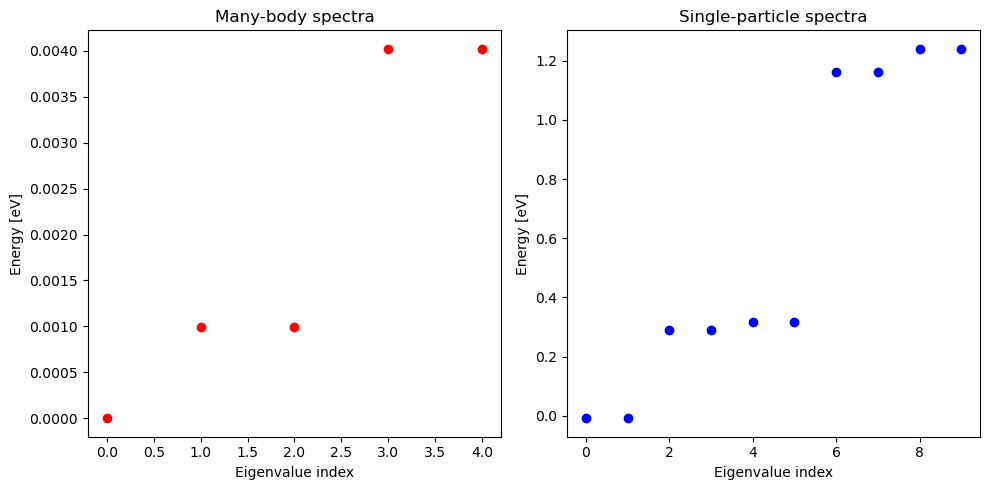

In [5]:
import scipy.linalg as lg
import numpy as np

fig = plt.figure(figsize=[10,5])

plt.subplot(1,2,1)
plt.title("Many-body spectra")
es = lg.eigvalsh(H.todense()) # compute eigenvalues
es = es - es[0] ; es = es[es<0.1] # retain only the relatively small ones
plt.scatter(range(len(es)),es,c="red") # plot eigenvalues
plt.xlabel("Eigenvalue index") ; plt.ylabel("Energy [eV]") ; plt.tight_layout()

# with the current parameters, this Hamiltonian describes a spin Hamiltonian like S111**2 for S=2

# plot the single particle spectra as a reference
plt.subplot(1,2,2)
plt.title("Single-particle spectra")
es = lg.eigvalsh(H_single.todense()) # compute eigenvalues
plt.scatter(range(len(es)),es,c="blue") # plot eigenvalues
plt.xlabel("Eigenvalue index") ; plt.ylabel("Energy [eV]") ; plt.tight_layout()